In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sqlalchemy import create_engine
from urllib.parse import quote_plus
from dotenv import load_dotenv
import os

load_dotenv()
password = quote_plus(os.getenv('DB_PASSWORD'))
DB_URL = f"postgresql://{os.getenv('DB_USER')}:{password}@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
engine = create_engine(DB_URL)
print("✅ Connected!")

✅ Connected!


In [3]:
query = """
SELECT
    ROUND(AVG(payment_value)::numeric, 2) as avg_order_value,
    ROUND(MIN(payment_value)::numeric, 2) as min_order,
    ROUND(MAX(payment_value)::numeric, 2) as max_order,
    COUNT(DISTINCT order_id) as total_orders
FROM order_payments
WHERE payment_value > 0;
"""
df_aov = pd.read_sql(query, engine)
print("📊 KPI 1 — Average Order Value (AOV)")
print(df_aov.to_string(index=False))

📊 KPI 1 — Average Order Value (AOV)
 avg_order_value  min_order  max_order  total_orders
          154.11       0.01   13664.08         99437


In [4]:
query = """
SELECT
    order_status,
    COUNT(*) as total_orders,
    ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 1) as percentage
FROM orders
GROUP BY order_status
ORDER BY total_orders DESC;
"""
df_status = pd.read_sql(query, engine)
print("📊 KPI 2 — Order Status Breakdown")
print(df_status.to_string(index=False))

📊 KPI 2 — Order Status Breakdown
order_status  total_orders  percentage
   delivered         96478        97.0
     shipped          1107         1.1
    canceled           625         0.6
 unavailable           609         0.6
    invoiced           314         0.3
  processing           301         0.3
     created             5         0.0
    approved             2         0.0


In [5]:
query = """
SELECT
    COALESCE(p.product_category_name, 'unknown') as category,
    COUNT(oi.order_id) as total_orders,
    ROUND(SUM(oi.price)::numeric, 2) as total_revenue,
    ROUND(AVG(oi.price)::numeric, 2) as avg_price
FROM order_items oi
JOIN products p ON oi.product_id = p.product_id
GROUP BY p.product_category_name
ORDER BY total_revenue DESC
LIMIT 10;
"""
df_cat = pd.read_sql(query, engine)
print("📊 KPI 3 — Top 10 Product Categories by Revenue")
print(df_cat.to_string(index=False))

📊 KPI 3 — Top 10 Product Categories by Revenue
              category  total_orders  total_revenue  avg_price
          beleza_saude          9670     1258681.34     130.16
    relogios_presentes          5991     1205005.68     201.14
       cama_mesa_banho         11115     1036988.68      93.30
         esporte_lazer          8641      988048.97     114.34
informatica_acessorios          7827      911954.32     116.51
      moveis_decoracao          8334      729762.49      87.56
            cool_stuff          3796      635290.85     167.36
 utilidades_domesticas          6964      632248.66      90.79
            automotivo          4235      592720.11     139.96
    ferramentas_jardim          4347      485256.46     111.63


In [6]:
query = """
WITH customer_counts AS (
    SELECT customer_id, COUNT(order_id) as num_orders
    FROM orders
    GROUP BY customer_id
)
SELECT
    COUNT(*) as total_customers,
    SUM(CASE WHEN num_orders > 1 THEN 1 ELSE 0 END) as repeat_customers,
    ROUND(SUM(CASE WHEN num_orders > 1 THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1) as repeat_rate_pct,
    ROUND(AVG(num_orders)::numeric, 2) as avg_orders_per_customer
FROM customer_counts;
"""
df_repeat = pd.read_sql(query, engine)
print("📊 KPI 4 — Repeat Customer Rate")
print(df_repeat.to_string(index=False))

📊 KPI 4 — Repeat Customer Rate
 total_customers  repeat_customers  repeat_rate_pct  avg_orders_per_customer
           99441                 0              0.0                      1.0


In [7]:
query = """
SELECT
    ROUND(AVG(EXTRACT(EPOCH FROM (order_delivered_customer_date - order_purchase_timestamp))/86400)::numeric, 1) as avg_delivery_days,
    ROUND(MIN(EXTRACT(EPOCH FROM (order_delivered_customer_date - order_purchase_timestamp))/86400)::numeric, 1) as min_days,
    ROUND(MAX(EXTRACT(EPOCH FROM (order_delivered_customer_date - order_purchase_timestamp))/86400)::numeric, 1) as max_days
FROM orders
WHERE order_delivered_customer_date IS NOT NULL
AND order_status = 'delivered';
"""
df_delivery = pd.read_sql(query, engine)
print("📊 KPI 5 — Average Delivery Time")
print(df_delivery.to_string(index=False))

📊 KPI 5 — Average Delivery Time
 avg_delivery_days  min_days  max_days
              12.6       0.5     209.6


In [8]:
query = """
SELECT
    ROUND(AVG(review_score)::numeric, 2) as avg_review_score,
    COUNT(*) as total_reviews,
    SUM(CASE WHEN review_score = 5 THEN 1 ELSE 0 END) as five_star,
    SUM(CASE WHEN review_score = 1 THEN 1 ELSE 0 END) as one_star,
    ROUND(SUM(CASE WHEN review_score >= 4 THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1) as positive_pct
FROM order_reviews;
"""
df_reviews = pd.read_sql(query, engine)
print("📊 KPI 6 — Customer Review Score")
print(df_reviews.to_string(index=False))

📊 KPI 6 — Customer Review Score
 avg_review_score  total_reviews  five_star  one_star  positive_pct
             4.09          99224      57328     11424          77.1


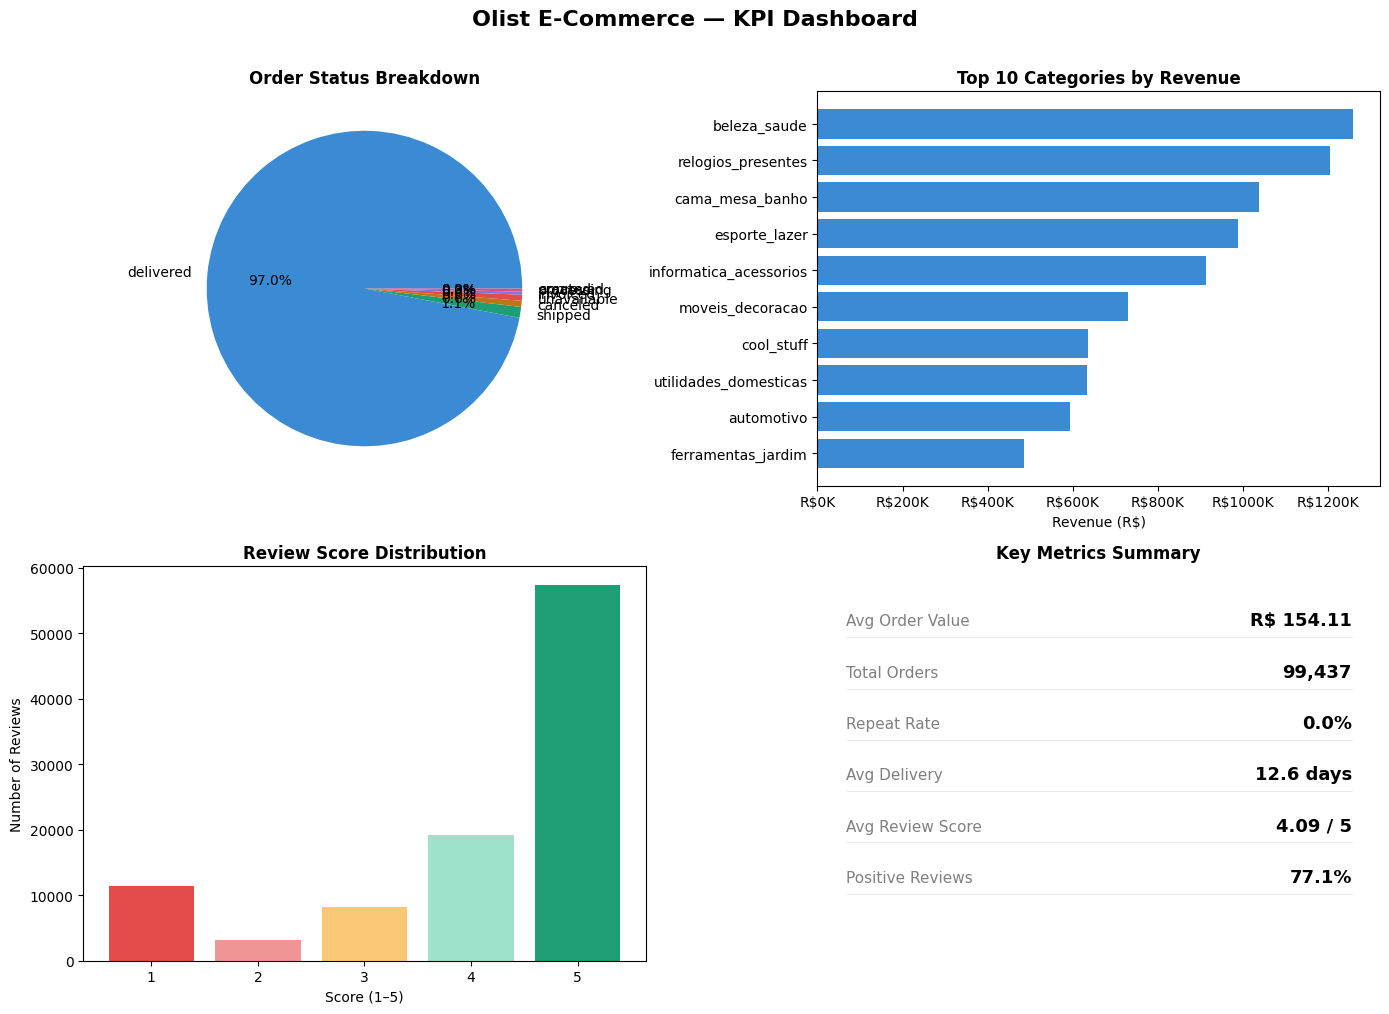

✅ KPI Dashboard saved!


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Olist E-Commerce — KPI Dashboard', fontsize=16, fontweight='bold', y=1.01)

# Chart 1 — Order Status pie
axes[0,0].pie(df_status['total_orders'],
              labels=df_status['order_status'],
              autopct='%1.1f%%',
              colors=['#3B8BD4','#1D9E75','#BA7517','#E24B4A','#7F77DD','#D4537E'])
axes[0,0].set_title('Order Status Breakdown', fontweight='bold')

# Chart 2 — Top categories horizontal bar
axes[0,1].barh(df_cat['category'][::-1], df_cat['total_revenue'][::-1], color='#3B8BD4')
axes[0,1].set_title('Top 10 Categories by Revenue', fontweight='bold')
axes[0,1].set_xlabel('Revenue (R$)')
axes[0,1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'R${x/1e3:.0f}K'))

# Chart 3 — Review score distribution
review_counts = pd.read_sql("SELECT review_score, COUNT(*) as count FROM order_reviews GROUP BY review_score ORDER BY review_score", engine)
colors = ['#E24B4A','#F09595','#FAC775','#9FE1CB','#1D9E75']
axes[1,0].bar(review_counts['review_score'], review_counts['count'], color=colors)
axes[1,0].set_title('Review Score Distribution', fontweight='bold')
axes[1,0].set_xlabel('Score (1–5)')
axes[1,0].set_ylabel('Number of Reviews')

# Chart 4 — KPI summary text (FIXED — no transform on axhline)
axes[1,1].axis('off')
kpi_text = [
    ('Avg Order Value',  f"R$ {df_aov['avg_order_value'].values[0]:,.2f}"),
    ('Total Orders',     f"{df_aov['total_orders'].values[0]:,}"),
    ('Repeat Rate',      f"{df_repeat['repeat_rate_pct'].values[0]}%"),
    ('Avg Delivery',     f"{df_delivery['avg_delivery_days'].values[0]} days"),
    ('Avg Review Score', f"{df_reviews['avg_review_score'].values[0]} / 5"),
    ('Positive Reviews', f"{df_reviews['positive_pct'].values[0]}%"),
]
for i, (label, value) in enumerate(kpi_text):
    y = 0.85 - i * 0.13
    axes[1,1].text(0.05, y, label, fontsize=11, color='gray',
                   transform=axes[1,1].transAxes)
    axes[1,1].text(0.95, y, value, fontsize=13, fontweight='bold',
                   ha='right', transform=axes[1,1].transAxes)
    axes[1,1].plot([0.05, 0.95], [y - 0.03, y - 0.03],
                   color='#e0e0e0', linewidth=0.5,
                   transform=axes[1,1].transAxes)

axes[1,1].set_title('Key Metrics Summary', fontweight='bold')

plt.tight_layout()
plt.savefig('dashboards/kpi_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ KPI Dashboard saved!")